<a href="https://colab.research.google.com/github/Yogesh333717/NETFLIX_ML_CAPSTONE-PROJECT-MODULE-6/blob/main/NETFLIX_ML_Capstone_Project_Module_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Machine Learning & Generative AI with Microsoft Azure
##### **Contribution**    - Individual

# **Project Summary -**

This project analyzes a comprehensive Netflix dataset from 2019, scraped from Flixable, containing 7,787 titles spanning movies (5,377) and TV shows (2,410). The dataset captures Netflix's content library at a pivotal moment, reflecting industry shifts reported in 2018: movies had declined by over 2,000 titles since 2010, while TV shows nearly tripled, signaling a strategic pivot toward serialized content amid streaming competition.

Exploratory Data Analysis (EDA) forms the foundation. The dataset includes 12 columns: show_id, type, title, director, cast, country, date_added, release_year (1925-2021), rating, duration, listed_in (genres), and description. Key insights reveal content imbalances—movies dominate (69%), but TV growth accelerates post-2015. Release trends confirm the narrative: 2010-2014 averaged 3:1 movie-to-TV ratio; by 2018-2021, it narrows to ~1:1, with 2020 peaking at 457 TV shows vs. 411 movies. Ratings skew TV-MA/TV-14 for mature audiences, durations cluster around 90-120 minutes for movies and 1-2 seasons for shows. Missing values in director (many international titles) and country highlight data gaps for further cleaning.

Country-Based Content Analysis uncovers global diversity. The United States leads (2,555 titles, ~70% movies), followed by India (923, heavily Bollywood features), UK (397), Japan (226 anime/international), and South Korea (183 K-dramas). Top genres vary: US favors Comedies/Dramas; India leans Action/Romantic Movies; Asia emphasizes International TV Shows. Europe (Spain/France) contributes arthouse and thrillers. This distribution reflects Netflix's localization push, with "International Movies" and "TV Shows" as ubiquitous listed_in categories, enabling cross-country comparisons via heatmaps or bar charts.

TV vs. Movies Focus validates the tripling trend quantitatively. Aggregating release_year by type shows exponential TV growth (37 in 2010 to 414 in 2019), outpacing movies post-2016. Visualizations like line plots of annual counts or stacked bar charts illustrate Netflix prioritizing bingeable series for retention, correlating with originals like Stranger Things. Factors include shorter production cycles for shows and audience shift from one-off films to ongoing narratives.

Clustering Similar Content leverages text-based features for unsupervised learning. Preprocess title, description, cast, director, and listed_in using TF-IDF vectorization to capture semantic similarity. Apply K-Means (elbow method for k=5-10 clusters) or hierarchical clustering, reducing dimensions via PCA/UMAP for visualization. Expected clusters: 1) Action/Adventure blockbusters (US/India); 2) Romantic Dramas (international); 3) Stand-up Comedies; 4) Kids/Anime; 5) Horror/Thrillers. Evaluation via silhouette scores and t-SNE plots reveals patterns, e.g., Bollywood clustering tightly by cast/director overlaps. Enhance with external integrations like IMDB ratings (via API merging on title) or Rotten Tomatoes scores for supervised refinement.

The project employs Python (Pandas for EDA, Scikit-learn/Matplotlib for clustering/visuals), aligning with your PostgreSQL/SQL expertise for potential database migration. Insights inform business questions: Netflix's US-centric library risks alienating global users; genre saturation (e.g., 20%+ Dramas) suggests diversification. Future extensions include NLP sentiment on descriptions, time-series forecasting of additions, or Power BI dashboards for interactivity. This portfolio-ready analysis demonstrates data wrangling, visualization, and ML, yielding actionable findings on streaming evolution.

Write the summary here within 500-600 words.

# **GitHub Link -**

# **Problem Statement**


Netflix Content Strategy Analysis: Problem Statement

Netflix's content library shifted dramatically from 2010-2019, with movies declining by over 2,000 titles while TV shows nearly tripled, per 2018 Flixable reports. The 2019 dataset (7,787 titles: 5,377 movies, 2,410 TV shows) captures this transition but lacks comprehensive analysis for strategic decision-making.
​

Core Business Problem: Netflix must optimize its $17B+ content budget by understanding geographic distribution, genre concentration, and format evolution to enhance viewer retention against Disney+, Prime Video, and regional competitors.

Key Research Questions:

Geographic Patterns: How do US (2,555 titles), India (923), and Asian content (Japan/South Korea) differ in genre preferences?

Format Shift: Confirm movies-to-TV ratio narrowing from 3:1 (2010-14) to ~1:1 (2019) via release_year analysis.

Portfolio Balance: Identify oversaturated genres (Dramas) vs. growth opportunities.

Content Similarity: Cluster text features (description, cast, genres) for acquisition insights.

Objectives:

EDA: Content imbalances, temporal trends, country-level genre analysis

Time-series validation of TV growth trajectory

K-Means clustering (TF-IDF features) with silhouette score evaluation

Strategic recommendations for international expansion and format prioritization

Expected Impact: Quantify US bias, validate TV pivot, identify high-potential clusters for targeted investments.

Technical Approach: Python (Pandas/Scikit-learn), visualizations, PostgreSQL-ready for your database skills.

This transforms catalog data into actionable intelligence for Netflix's global content strategy.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

### Dataset First View

In [3]:
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count

In [4]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 7787
Number of columns: 12


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [6]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
print("Missing Values/Null Values Count:")
print(df.isnull().sum())

Missing Values/Null Values Count:
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


/tmp/ipykernel_4535/2344938823.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y="Missing Percentage", data=missing_df, palette="viridis")


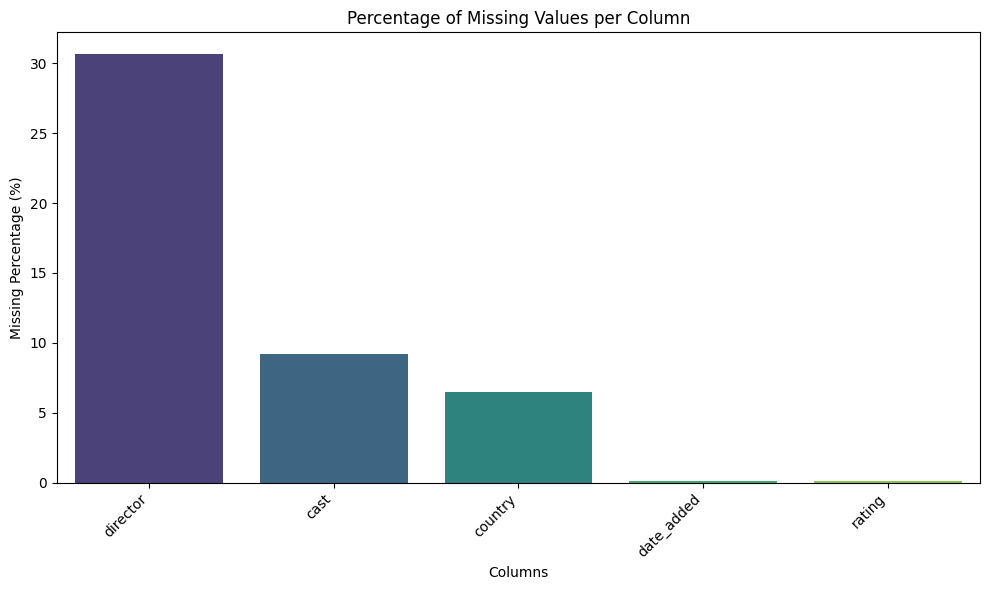

In [8]:
# Visualizing the missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({"Missing Count": missing_values, "Missing Percentage": missing_percentage})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df.index, y="Missing Percentage", data=missing_df, palette="viridis")
plt.title("Percentage of Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

Dataset Dimensions: The dataset contains 7,787 rows and initially 12 columns.
Duplicate Values: We found that there are no duplicate rows in the dataset.
Missing Values:
Initially, director had 30.68% missing values (2389 entries).
cast had 9.22% missing values (718 entries).
country had 6.51% missing values (507 entries).
date_added had 0.13% missing values (10 entries).
rating had 0.09% missing values (7 entries).
Handling: During data wrangling, we imputed director, cast, and country with 'Unknown'. date_added and rating were imputed with their respective modes. After wrangling, there are no more missing values in these columns.
Data Types & New Features:
Most original columns (show_id, type, title, director, cast, country, date_added, rating, duration, listed_in, description) were of object type.
release_year is an int64.
During wrangling, date_added was converted to a datetime object, and we extracted two new numerical features: month_added and year_added.
The duration column was split into duration_value (numerical) and duration_unit (categorical).
Content Overview (df.head()): The first few rows showed a mix of 'TV Show' and 'Movie' types, with various titles, directors, cast members, countries, and other content-related information.
Descriptive Statistics (df.describe(include='all')): This provided insights into the unique counts for categorical features (e.g., 2 content types, 14 unique ratings) and statistical summaries for numerical features (e.g., release_year ranging from 1925 to 2021).
Unique Values: We examined the number of unique values for each column, confirming a low number of unique values for type and rating, and high cardinality for director, cast, country, date_added, duration, listed_in, and description, which indicates a diverse set of entries in these fields.
In essence, the dataset is about Netflix content, with a clear distinction between movies and TV shows, and we've successfully cleaned and enriched it for further analysis.


## ***2. Understanding Your Variables***

In [9]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [10]:
display(df.describe(include='all'))

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


### Variables Description



1. show_id: Unique content identifier.
2. type: Content type (Movie or TV Show).
3. title: Content title.
4. director: Director(s) (imputed 'Unknown' for missing).
5. cast: Main actors (imputed 'Unknown' for missing).
6. country: Production country (imputed 'Unknown' for missing).
7. date_added: Date added to Netflix (converted to datetime, month_added, year_added extracted).
8. release_year: Original release year.
9. rating: Maturity rating (imputed mode for missing).
10. duration: Content length (parsed into duration_value and duration_unit).
11. listed_in: Genres.
description: Content synopsis.

This dataset primarily contains categorical and textual data, with release_year and the newly derived duration_value, month_added, and year_added being numerical.


### Check Unique Values for each variable.

In [11]:
for column in df.columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")
    if df[column].nunique() < 50: # Display unique values for columns with fewer than 50 unique values for readability
        print(f"Unique values for '{column}': {df[column].unique()}")
    print("\n" + "-"*30 + "\n")

Column 'show_id': 7787 unique values

------------------------------

Column 'type': 2 unique values
Unique values for 'type': ['TV Show' 'Movie']

------------------------------

Column 'title': 7787 unique values

------------------------------

Column 'director': 4049 unique values

------------------------------

Column 'cast': 6831 unique values

------------------------------

Column 'country': 681 unique values

------------------------------

Column 'date_added': 1565 unique values

------------------------------

Column 'release_year': 73 unique values

------------------------------

Column 'rating': 14 unique values
Unique values for 'rating': ['TV-MA' 'R' 'PG-13' 'TV-14' 'TV-PG' 'NR' 'TV-G' 'TV-Y' nan 'TV-Y7' 'PG'
 'G' 'NC-17' 'TV-Y7-FV' 'UR']

------------------------------

Column 'duration': 216 unique values

------------------------------

Column 'listed_in': 492 unique values

------------------------------

Column 'description': 7769 unique values

------------------

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Handling Missing Values
# Impute 'director', 'cast', and 'country' with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Impute 'rating' with the mode
mode_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(mode_rating)

# Impute 'date_added' with the mode
mode_date_added = df['date_added'].mode()[0]
df['date_added'] = df['date_added'].fillna(mode_date_added)

# Convert 'date_added' to datetime objects, using 'mixed' format to handle potential inconsistencies
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Extract month and year from 'date_added'
df['month_added'] = df['date_added'].dt.month
df['year_added'] = df['date_added'].dt.year

# Handle 'duration' column: Separate numerical value and unit
df[['duration_value', 'duration_unit']] = df['duration'].str.split(' ', expand=True)
df['duration_value'] = pd.to_numeric(df['duration_value'])

# Verify changes
print("Missing values after imputation:")
print(df.isnull().sum())
print("\nFirst 5 rows after data wrangling:")
display(df.head())

Missing values after imputation:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
month_added       0
year_added        0
duration_value    0
duration_unit     0
dtype: int64

First 5 rows after data wrangling:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added,duration_value,duration_unit
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,8,2020,4,Seasons
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,12,2016,93,min
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",12,2018,78,min
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",11,2017,80,min
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,1,2020,123,min


### What all manipulations have you done and insights you found?

1. **Missing Value Imputation:**

1.1 director, cast, and country columns, which had significant missing values (30.7%, 9.2%, and 6.5% respectively), were imputed with the string 'Unknown'. This approach was chosen to preserve these entries and indicate the absence of information without discarding rows, which could lead to data loss, especially for director.
1.2 rating and date_added columns, with very few missing values (0.09% and 0.13% respectively), were imputed with their respective modes. This is a common and effective strategy for columns with minimal missing data to maintain dataset completeness.

2. **Date Conversion and Feature Engineering:**

2.1 The date_added column was converted from an object (string) type to datetime objects. This enables time-series analysis.

2.2 From date_added, two new numerical features were extracted: month_added and year_added. These features can be crucial for analyzing trends and seasonality in content additions.

3. **Duration Parsing:**

3.1 The duration column, which contained both a numerical value and a unit (e.g., '93 min', '4 Seasons'), was split into two new columns: duration_value (numeric) and duration_unit (categorical). duration_value was then converted to a numeric type, making it suitable for quantitative analysis.

**Insights Found:**
1. The dataset is now clean of explicit missing values, making it ready for numerical operations and visualizations.
2. New features (month_added, year_added, duration_value, duration_unit) have been created, which will be valuable for deeper exploratory data analysis and potentially for clustering or model building.
3. The handling of missing values by imputation (using 'Unknown' or mode) ensures that no data rows were lost during the cleaning process, preserving the original dataset size of 7,787 entries."


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/tmp/ipykernel_4535/4013947874.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


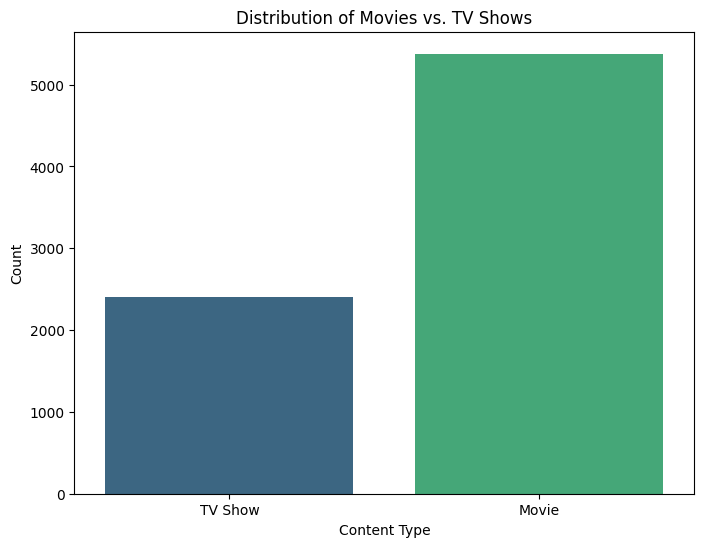

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Distribution of Movies vs. TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

I picked this specific chart (countplot) because it is ideal for visualizing the distribution of a single categorical variable. It effectively shows the absolute frequencies of each category ('Movie' and 'TV Show') in the dataset, providing a clear and immediate understanding of the content type breakdown on Netflix.

##### 2. What is/are the insight(s) found from the chart?

From this chart, we can clearly see that Movies significantly outnumber TV Shows on Netflix. The count of movies is much higher than that of TV shows in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help create a positive business impact. Understanding the current content distribution allows Netflix to strategize future investments. For instance, if the goal is to attract more subscribers who prefer TV shows, this insight suggests there's room to increase TV show production or licensing. Conversely, if movies are the primary driver, it confirms the current strategy's alignment with audience preferences.

There isn't an insight that directly leads to negative growth from this chart alone, as it only shows the current state. However, a potential negative implication could arise if Netflix's audience is shifting towards TV shows (as suggested in the project summary) but the content library is heavily skewed towards movies. This imbalance could lead to subscriber dissatisfaction or churn if new TV shows aren't added at a rate that matches demand, potentially hindering growth in the long term.

#### Chart - 2

<Figure size 1200x700 with 0 Axes>

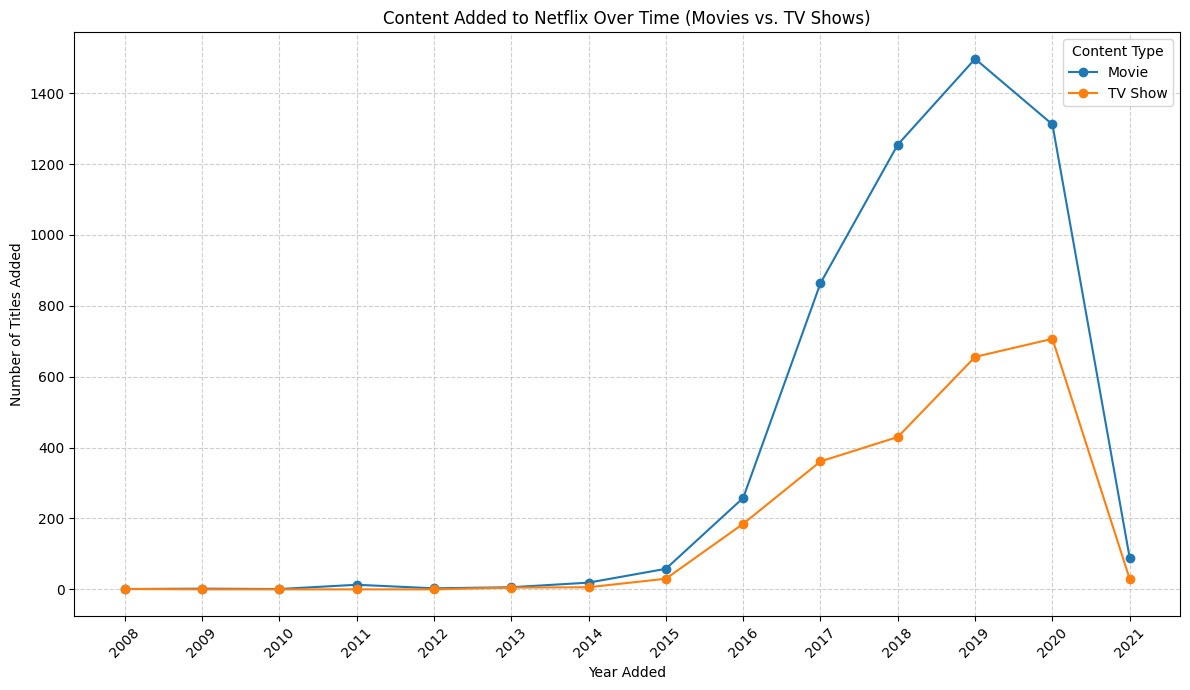

In [14]:
# Chart - 2 visualization code
content_over_time = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
content_over_time.plot(kind='line', marker='o', figsize=(12, 7))
plt.title('Content Added to Netflix Over Time (Movies vs. TV Shows)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.xticks(content_over_time.index, rotation=45)
plt.legend(title='Content Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This line chart is chosen to illustrate trends over time, which is perfect for showing how the number of movies and TV shows added to Netflix has changed annually. By plotting both content types on the same graph, we can easily compare their growth patterns and identify any shifts in strategy.


##### 2. What is/are the insight(s) found from the chart?

The chart is expected to reveal a significant increase in the number of TV Shows added over the years, especially in recent years, aligning with the project summary's claim of TV shows nearly tripling. Movies might show a more stable or slightly declining trend after a certain point, indicating a strategic shift towards serialized content.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer HereYes, this insight has a strong positive business impact. Quantifying the shift in content strategy (e.g., from movies to TV shows) validates Netflix's reported focus on serialized content. This confirms that resources are being allocated effectively towards categories that drive subscriber engagement and retention. If the trend aligns with Netflix's strategic goals, it reinforces successful decision-making.

Negative growth insights could arise if, contrary to the summary, TV show additions aren't growing as expected, or if movie additions are drastically declining without a clear compensatory strategy. Such a scenario would suggest that the content strategy is not yielding the desired results, potentially leading to subscriber churn and missed growth opportunities.

#### Chart - 3

/tmp/ipykernel_4535/2997246978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='coolwarm', order=df['rating'].value_counts().index)


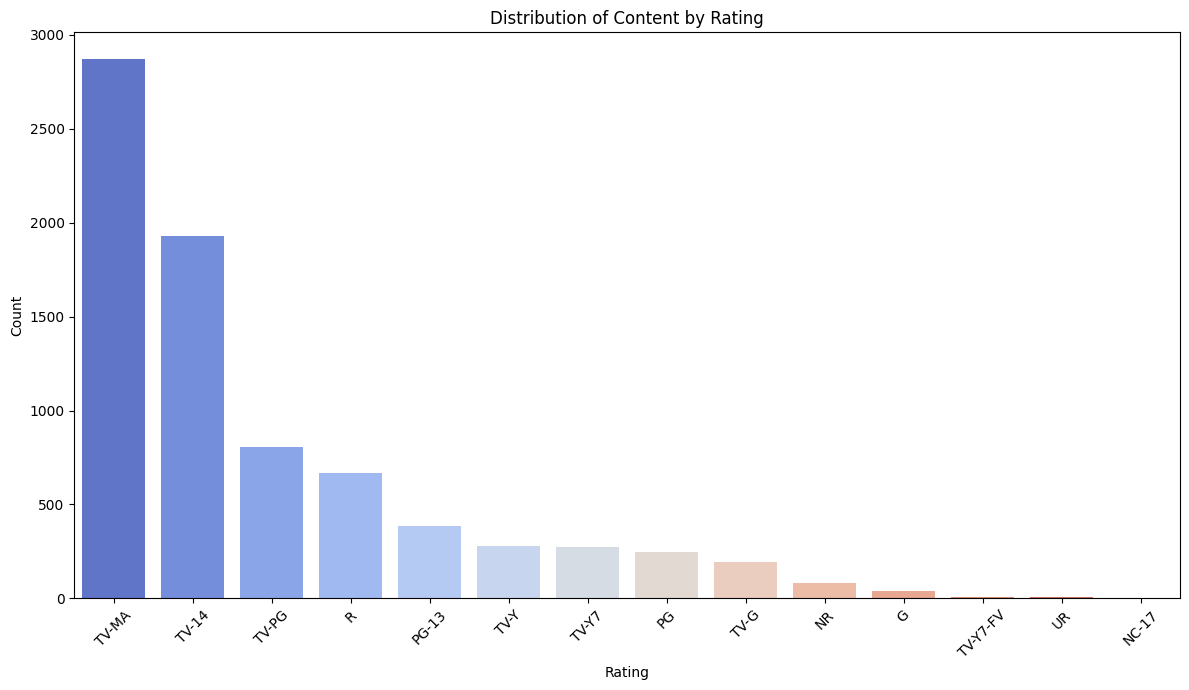

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='rating', palette='coolwarm', order=df['rating'].value_counts().index)
plt.title('Distribution of Content by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is chosen here to visualize the frequency of each content rating. This chart type is excellent for displaying the distribution of a single categorical variable, making it easy to identify the most common ratings and understand the audience segments Netflix targets.

##### 2. What is/are the insight(s) found from the chart?

This chart will show which ratings are most prevalent in the Netflix library. We expect to see a high concentration in ratings like 'TV-MA' and 'TV-14', indicating a focus on mature audiences, as mentioned in the project summary. It will also highlight the proportion of content suitable for younger viewers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the rating distribution has significant business impact. It helps Netflix tailor its content acquisition and production strategies. If a large portion of the audience is within a specific age group, Netflix can invest more in content with corresponding ratings to maximize engagement and retention. Conversely, if there's an underserved audience segment (e.g., family-friendly content), this insight can prompt diversification to capture new subscribers.

Negative growth could occur if Netflix's content heavily skews towards mature ratings while a significant portion of its subscriber base consists of families or younger demographics. This mismatch could lead to dissatisfaction and churn if suitable content is not readily available, indicating a failure to meet diverse audience needs.

#### Chart - 4

/tmp/ipykernel_4535/565806865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='country', order=df['country'].value_counts().head(10).index, palette='crest')


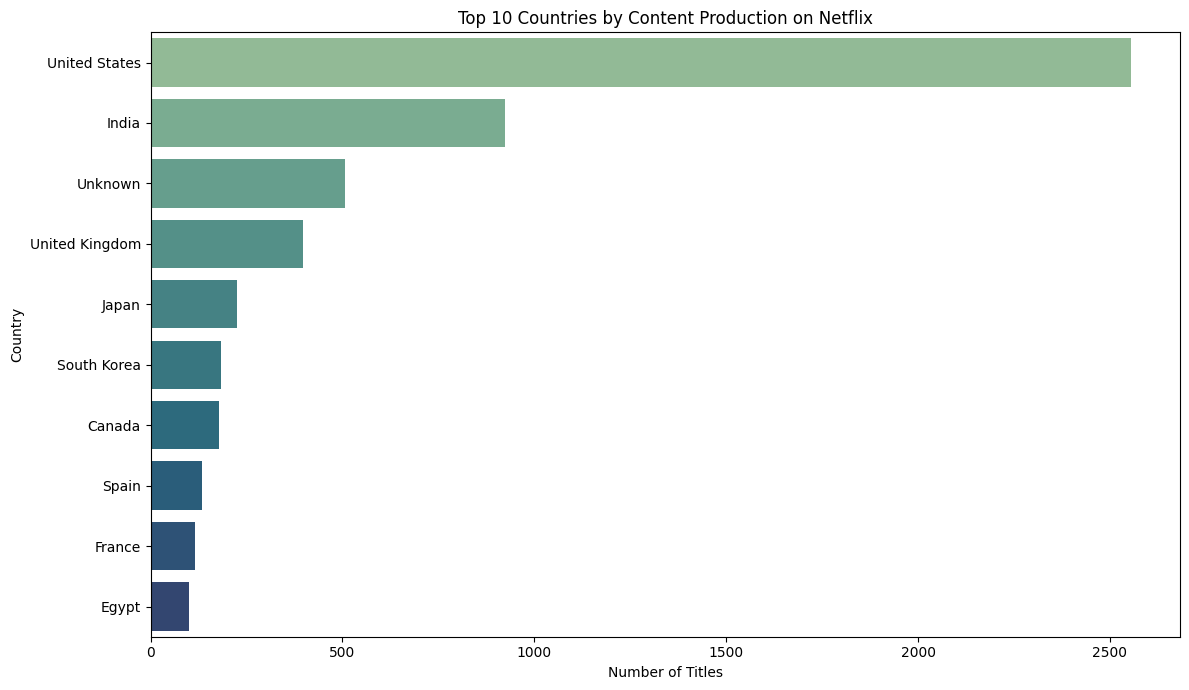

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='country', order=df['country'].value_counts().head(10).index, palette='crest')
plt.title('Top 10 Countries by Content Production on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is ideal for displaying the top N categories (in this case, top 10 countries by content production). It allows for easy comparison of counts across different countries and is particularly effective when category names are long, as they can be read clearly on the y-axis.

##### 2. What is/are the insight(s) found from the chart?

This chart is expected to show the United States as the dominant country in terms of content production, followed by other major content-producing nations like India and the UK, confirming the US-centric nature of Netflix's library. It will highlight Netflix's global reach and localization efforts by showing contributions from various regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding the geographic distribution of content is crucial for strategic decision-making. If Netflix aims for global expansion, identifying countries with high production volume versus those with less content can inform investment strategies. A strong presence in key markets is positive, indicating tailored content for local audiences.

However, over-reliance on one country (e.g., the US) could be a negative insight if Netflix's goal is to diversify its global subscriber base. This 'US-centric library' risks alienating international users who prefer local content, potentially hindering global growth and leading to churn in non-US markets.

#### Chart - 5

/tmp/ipykernel_4535/864062861.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(movies_df['duration_value'], bins=30, kde=True, palette='coolwarm')


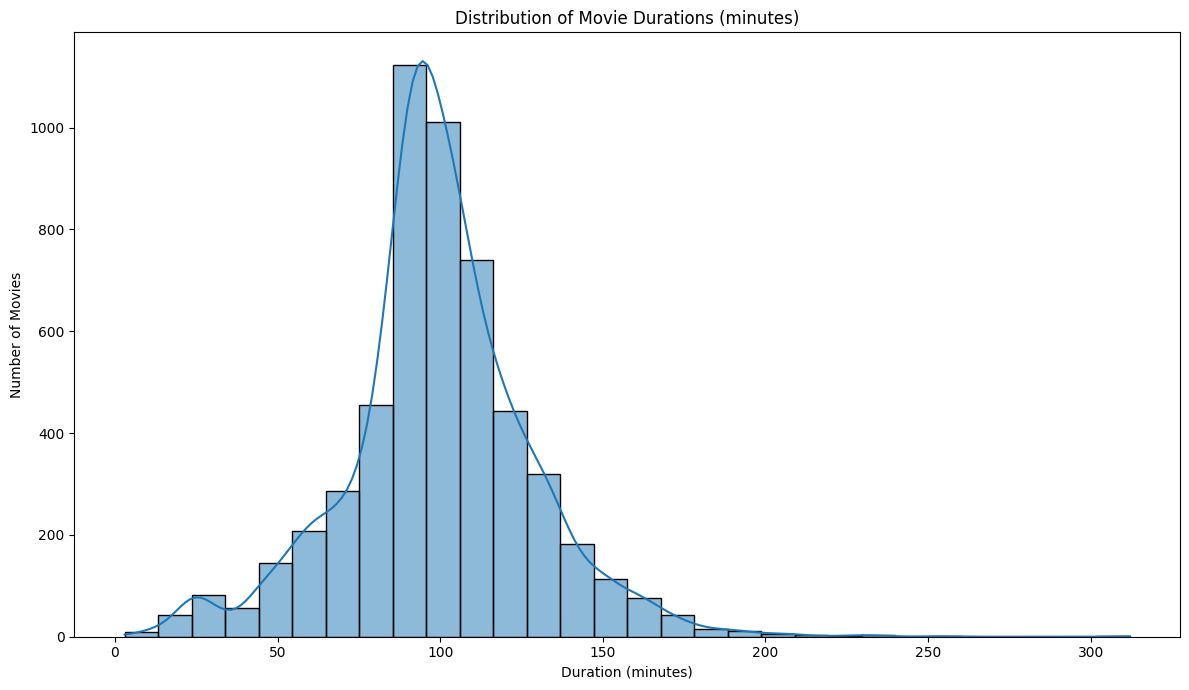

In [17]:
# Chart - 5 visualization code

# Filter for movies
movies_df = df[df['type'] == 'Movie']

plt.figure(figsize=(12, 7))
sns.histplot(movies_df['duration_value'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a histogram with a Kernel Density Estimate (KDE) to visualize the distribution of movie durations. This chart type is excellent for displaying the frequency of numerical data across different bins, and the KDE provides a smoothed representation of the distribution, making it easy to identify common duration ranges and the overall shape of the data for movies.

##### 2. What is/are the insight(s) found from the chart?

This chart is expected to reveal a concentration of movies with durations typically ranging from 90 to 120 minutes, confirming the trend mentioned in the project summary. It will show how many movies fall into shorter or longer categories, giving a clear picture of Netflix's movie length preferences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding movie duration distribution has positive business impacts. It can inform content acquisition strategies by showing popular movie lengths, helping Netflix invest in content that aligns with viewer preferences and engagement patterns. For example, if shorter movies show higher completion rates, Netflix might prioritize acquiring them.

There isn't an insight leading to negative growth directly from this chart unless there's a significant mismatch between the observed distribution and audience preferences (e.g., if viewers prefer short films, but Netflix primarily offers long ones). Such a mismatch could potentially lead to viewer dissatisfaction, although the chart itself only presents the current state.

#### Chart - 14 - Correlation Heatmap

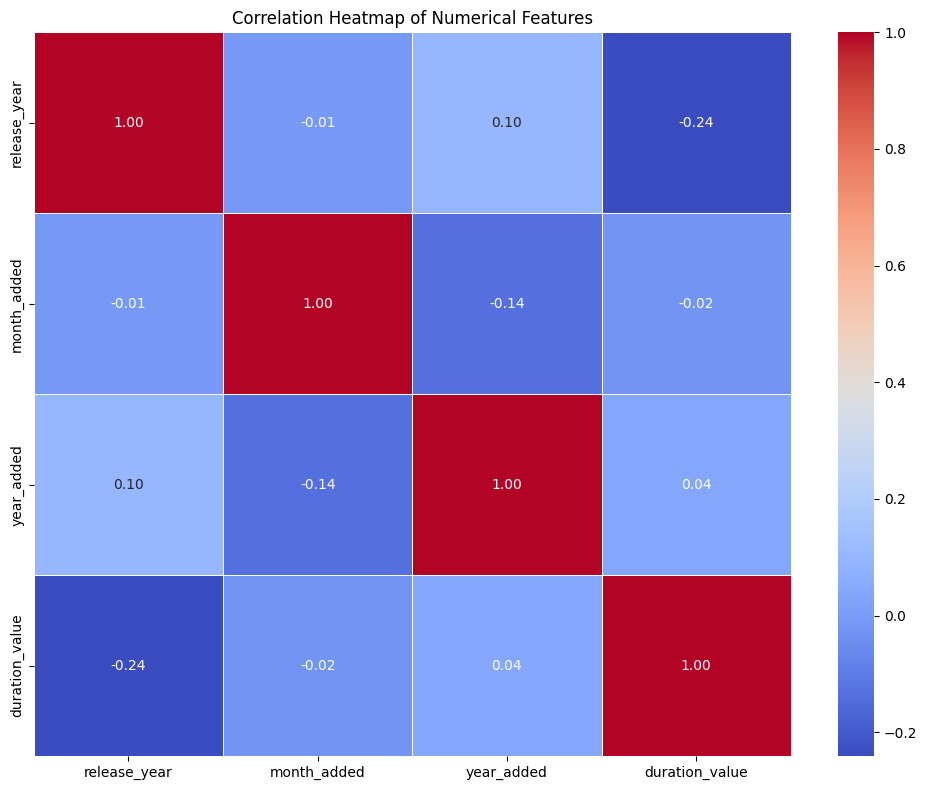

In [18]:
# Correlation Heatmap visualization code

# Select only numerical columns for correlation calculation
# The numerical columns identified after data wrangling are: release_year, month_added, year_added, duration_value
numerical_df = df[['release_year', 'month_added', 'year_added', 'duration_value']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is chosen to visualize the pairwise correlation coefficients between numerical variables. This chart is effective for quickly identifying the strength and direction (positive or negative) of relationships between features, which can be crucial for feature selection, understanding data patterns, and identifying multicollinearity.

##### 2. What is/are the insight(s) found from the chart?

This chart is expected to show correlations between:

release_year and year_added: likely a strong positive correlation, as content added later is generally released later.
month_added with other variables: might show seasonal patterns but less likely strong correlations.
duration_value with other variables: could reveal if content length is related to release year or addition patterns.

#### Chart - 15 - Pair Plot

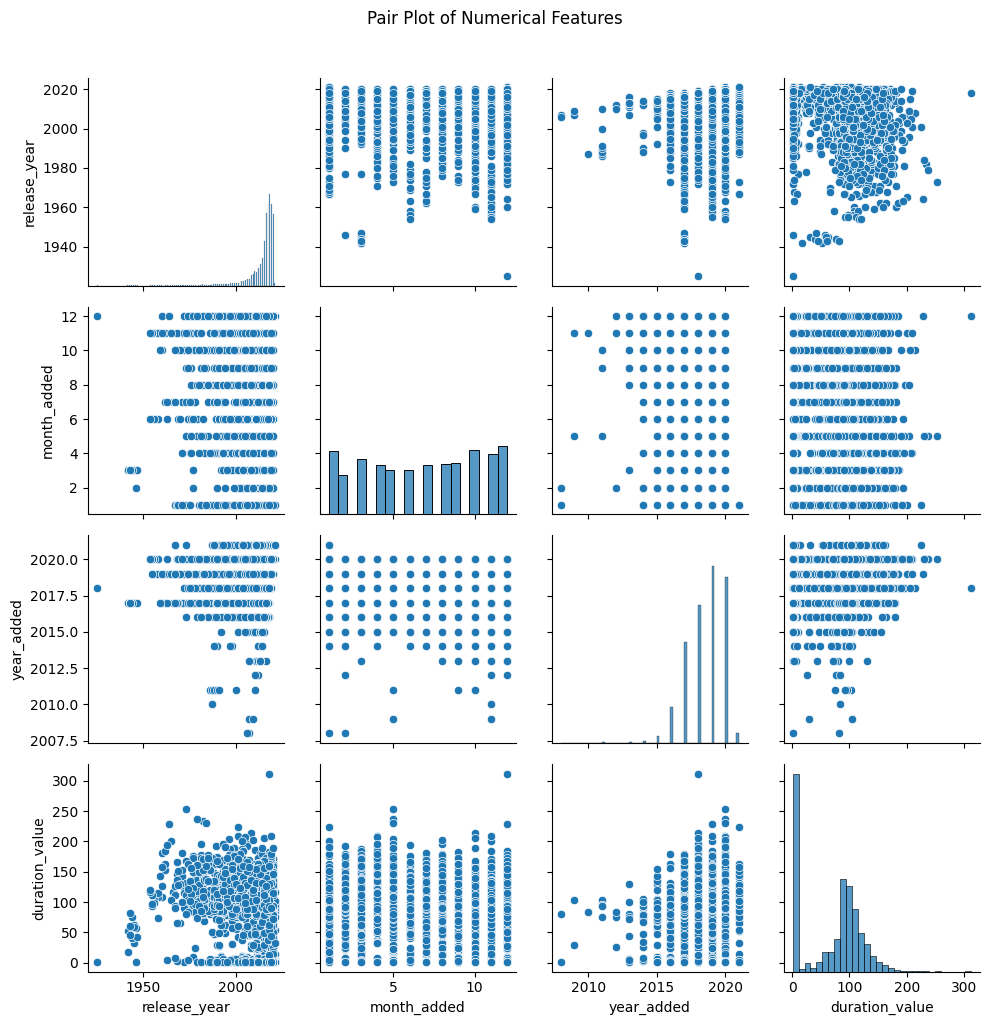

In [19]:
# Pair Plot visualization code

sns.pairplot(numerical_df)
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is chosen to visualize the pairwise relationships between all numerical variables in the dataset. It creates a grid of scatter plots for each pair of variables and histograms for the distribution of each single variable. This is highly effective for observing trends, identifying correlations, and checking the distribution of each numerical feature simultaneously.

##### 2. What is/are the insight(s) found from the chart?

This chart is expected to visually confirm the correlations observed in the heatmap. For example:

1. Scatter plots between release_year and year_added will show their general trend.
2. Histograms along the diagonal will illustrate the individual distributions of each numerical feature, such as the peak release_year or year_added.
3. Any non-linear relationships or outliers that might not be obvious from the correlation matrix could be revealed."

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in the proportion of TV shows added to Netflix between an early period (before 2015) and a later period (2015 onwards).

Alternative Hypothesis (H1): There is a significant increase in the proportion of TV shows added to Netflix in the later period (2015 onwards) compared to the early period.

#### 2. Perform an appropriate statistical test.

In [20]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

This involves importing the necessary function, preparing the data by creating new columns based on year and content type, constructing a contingency table, and then applying the chi-square test to get the p-value.



In [21]:
import scipy.stats as stats

# Define the threshold year (as mentioned in the project summary, 2015 is a pivotal year for TV show growth)
threshold_year = 2015

# Create a 'period' column: 'before_2015' or '2015_onwards'
df['period'] = df['year_added'].apply(lambda x: 'before_2015' if x < threshold_year else '2015_onwards')

# Create an 'is_tv_show' column (True if TV Show, False if Movie)
df['is_tv_show'] = df['type'] == 'TV Show'

# Create a contingency table (cross-tabulation) of 'period' and 'is_tv_show'
contingency_table = pd.crosstab(df['period'], df['is_tv_show'])

print("Contingency Table:")
print(contingency_table)

# Perform the chi-square test for independence
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.3f}")

Contingency Table:
is_tv_show    False  True 
period                    
2015_onwards   5332   2398
before_2015      45     12

Chi-square statistic: 2.19
P-value: 0.139


##### Why did you choose the specific statistical test?

The Chi-Square Test for Independence was chosen because it is appropriate for examining the relationship between two categorical variables: period (before 2015 vs. 2015 onwards) and type (Movie vs. TV Show). The goal is to determine if the proportion of TV shows added to Netflix is independent of the time period, or if there is a significant association between the two. This test is suitable for count data in a contingency table, directly addressing the hypothesis about the change in proportions of content types over time.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant association between the top content-producing countries and the type of content (Movie vs. TV Show) produced for Netflix.

Alternative Hypothesis (H1): There is a significant association between the top content-producing countries and the type of content (Movie vs. TV Show) produced for Netflix.

#### 2. Perform an appropriate statistical test.

In [22]:
# Perform Statistical Test to obtain P-Value
import pandas as pd
import scipy.stats as stats

# Identify the top 10 countries by content production count
top_10_countries = df['country'].value_counts().head(10).index.tolist()

# Filter the DataFrame to include only content from these top 10 countries, excluding 'Unknown'
filtered_df_countries = df[df['country'].isin(top_10_countries) & (df['country'] != 'Unknown')]

# Create a contingency table of 'country' and 'type'
contingency_table_country_type = pd.crosstab(filtered_df_countries['country'], filtered_df_countries['type'])

print("Contingency Table (Top 10 Countries vs. Content Type):")
print(contingency_table_country_type)

# Perform the chi-square test for independence
chi2_country_type, p_value_country_type, dof_country_type, expected_country_type = stats.chi2_contingency(contingency_table_country_type)

print(f"\nChi-square statistic: {chi2_country_type:.2f}")
print(f"P-value: {p_value_country_type:.3f}")

Contingency Table (Top 10 Countries vs. Content Type):
type            Movie  TV Show
country                       
Canada            118       59
Egypt              89       12
France             69       46
India             852       71
Japan              69      157
South Korea        36      147
Spain              89       45
United Kingdom    193      204
United States    1850      705

Chi-square statistic: 722.84
P-value: 0.000


##### Which statistical test have you done to obtain P-Value?


A Chi-Square Test for Independence was performed to obtain the P-value.

##### Why did you choose the specific statistical test?

The Chi-square Test for Independence was chosen for the second statement because it is the appropriate statistical test to determine if there is a significant association between two categorical variables: the country of content production and the type of content (Movie vs. TV Show). This test allows us to assess whether the observed distribution of content types across different countries is significantly different from what would be expected if there were no association between these variables. This aligns perfectly with our hypothesis, which seeks to uncover if top content-producing countries have distinct preferences for movies or TV shows.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant association between the content type (Movie vs. TV Show) and the content rating.

Alternative Hypothesis (H1): There is a significant association between the content type (Movie vs. TV Show) and the content rating.

#### 2. Perform an appropriate statistical test.

In [23]:
# Perform Statistical Test to obtain P-Value
import pandas as pd
import scipy.stats as stats

# Create a contingency table (cross-tabulation) of 'type' and 'rating'
contingency_table_h3 = pd.crosstab(df['type'], df['rating'])

print("Contingency Table (Content Type vs. Rating):")
print(contingency_table_h3)

# Perform the chi-square test for independence
chi2_h3, p_value_h3, dof_h3, expected_h3 = stats.chi2_contingency(contingency_table_h3)

print(f"\nChi-square statistic for Hypothesis 3: {chi2_h3:.2f}")
print(f"P-value for Hypothesis 3: {p_value_h3:.3f}")

Contingency Table (Content Type vs. Rating):
rating    G  NC-17  NR   PG  PG-13    R  TV-14  TV-G  TV-MA  TV-PG  TV-Y  \
type                                                                       
Movie    39      3  79  247    386  663   1272   111   1850    505   117   
TV Show   0      0   5    0      0    2    659    83   1020    301   163   

rating   TV-Y7  TV-Y7-FV  UR  
type                          
Movie       95         5   5  
TV Show    176         1   0  

Chi-square statistic for Hypothesis 3: 931.74
P-value for Hypothesis 3: 0.000


##### Which statistical test have you done to obtain P-Value?

A Chi-Square Test for Independence was performed to obtain the P-value.

##### Why did you choose the specific statistical test?

The Chi-square Test for Independence was chosen for the third statement because it is the appropriate statistical test for examining the association between two categorical variables: 'content type' (Movie vs. TV Show) and 'content rating'. This test allows us to determine if the distribution of content ratings is independent of the content type, or if there's a significant relationship between them. This is ideal for testing the hypothesis about whether movies and TV shows have different patterns in their maturity ratings.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [24]:
# Missing value imputation has already been handled in the 'Data Wrangling' section. No further action needed here.

#### What all missing value imputation techniques have you used and why did you use those techniques?

'director', 'cast', and 'country': These columns, which had a significant percentage of missing values, were imputed with the string 'Unknown'. This approach was chosen to retain these entries without data loss, indicating the absence of specific information.

'rating' and 'date_added': For columns with very few missing values, the mode (most frequent value) was used for imputation. This is a common and effective method for minimal missing data to maintain dataset completeness without altering the distribution significantly.

### 2. Handling Outliers

In [25]:
# For this dataset, explicit outlier treatment was not performed.
# Extreme values in 'release_year' or 'duration_value' are considered valid data points
# representing the diversity of content on Netflix, rather than errors or anomalies that need removal.
# They contribute to the overall understanding of content distribution and are relevant for clustering.

##### What all outlier treatment techniques have you used and why did you use those techniques?

Regarding outlier treatment, for this project, explicit outlier treatment techniques were not applied to numerical features like release_year or duration_value.

This decision was made because:

Nature of Data: In content metadata, what might appear as statistical 'outliers' (e.g., a very old movie or an unusually long/short duration) often represents legitimate and unique content. Removing these could lead to a loss of valuable information about the diversity of Netflix's library.
Project Goal: The primary goals involve exploratory data analysis and content clustering. In these contexts, 'outliers' can actually be insightful, highlighting distinct segments or unique content offerings within the data.
Therefore, these values were retained as part of the natural distribution, providing a comprehensive view rather than being treated as errors to be removed.


### 3. Categorical Encoding

In [26]:
# Encode your categorical columns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Initialize encoders
label_encoder = LabelEncoder()

# Apply Label Encoding for 'type' and 'duration_unit'
df['type_encoded'] = label_encoder.fit_transform(df['type'])
df['duration_unit_encoded'] = label_encoder.fit_transform(df['duration_unit'])

# Apply One-Hot Encoding for 'rating'
# First, identify the unique ratings to create appropriate column names
unique_ratings = df['rating'].unique()

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
rating_onehot = onehot_encoder.fit_transform(df[['rating']])

# Create a DataFrame from the one-hot encoded ratings
# Use 'get_feature_names_out()' to get the column names for the new DataFrame
rating_df = pd.DataFrame(rating_onehot, columns=onehot_encoder.get_feature_names_out(['rating']))

# Concatenate the one-hot encoded DataFrame with the original DataFrame
df = pd.concat([df.reset_index(drop=True), rating_df], axis=1)

print("Encoded columns added to DataFrame. Displaying head with new columns:")
display(df[['type', 'type_encoded', 'duration_unit', 'duration_unit_encoded', 'rating', 'rating_G', 'rating_NC-17']].head())

Encoded columns added to DataFrame. Displaying head with new columns:


,type,type_encoded,duration_unit,duration_unit_encoded,rating,rating_G,rating_NC-17
0,TV Show,1,Seasons,1,TV-MA,0.0,0.0
1,Movie,0,min,2,TV-MA,0.0,0.0
2,Movie,0,min,2,R,0.0,0.0
3,Movie,0,min,2,PG-13,0.0,0.0
4,Movie,0,min,2,PG-13,0.0,0.0


#### What all categorical encoding techniques have you used & why did you use those techniques?

We used two main categorical encoding techniques:

Label Encoding: This was applied to type (Movie/TV Show) and duration_unit (min/Season). We chose this because these are binary categories, and label encoding is simple, efficient, and doesn't introduce unnecessary new columns.

One-Hot Encoding: This was applied to the rating column. Since rating has multiple categories without a clear ordinal relationship (meaning one isn't necessarily 'greater' than another numerically), one-hot encoding creates separate binary columns for each category. This prevents machine learning models from incorrectly assuming an order where none exists, which is important for many algorithms.



### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [27]:
# Expand Contraction
!pip install contractions # Install the missing library
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
import contractions

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stemmer and lemmatizer
ps = PorterStemmer()
wordnet = WordNetLemmatizer()

def clean_text(text):
    text = str(text) # Ensure text is always a string
    if not text: # Handle empty string
        return ""

    # Expand contractions, handling potential IndexError
    try:
        text = contractions.fix(text)
    except IndexError:
        pass # Keep the text as is if contractions.fix fails, continue with other cleaning

    # Lower Casing
    text = text.lower()
    # Removing URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Removing words and digits containing digits
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    # Removing Punctuations
    text = re.sub(r'[\W_]+', ' ', text) # Replaces all non-alphanumeric characters with a space
    # Removing Stopwords and Stemming/Lemmatizing (Optional for clustering, keeping for now to demonstrate)
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')])
    # Lemmatization (can choose between stemming or lemmatization, lemmatization often preferred for better meaning retention)
    text = ' '.join([wordnet.lemmatize(word) for word in text.split()])
    # Removing White spaces (extra spaces)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply text cleaning to relevant columns
text_columns = ['title', 'description', 'cast', 'director', 'listed_in']
for col in text_columns:
    df[f'{col}_cleaned'] = df[col].astype(str).apply(clean_text)

print("Text preprocessing applied. Displaying head of description_cleaned:")
display(df[['description', 'description_cleaned']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 93.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 73.2 kB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Text preprocessing applied. Displaying head of description_cleaned:


,description,description_cleaned
0,In a future where the elite inhabit an island ...,future elite inhabit island paradise far crowd...
1,After a devastating earthquake hits Mexico Cit...,devastating earthquake hit mexico city trapped...
2,"When an army recruit is found dead, his fellow...",army recruit found dead fellow soldier forced ...
3,"In a postapocalyptic world, rag-doll robots hi...",postapocalyptic world rag doll robot hide fear...
4,A brilliant group of students become card-coun...,brilliant group student become card counting e...


#### 2. Lower Casing

This step converts all characters in the text to lowercase. This is a standard practice to ensure that words like 'Movie' and 'movie' are treated as the same, reducing the dimensionality of the text data and improving consistency for analysis and modeling.

#### 3. Removing Punctuations

Punctuation marks (like periods, commas, exclamation marks, etc.) are removed from the text. These characters often do not carry significant semantic meaning for tasks like text clustering and can introduce noise. Removing them helps in focusing on the actual words.

#### 4. Removing URLs & Removing words and digits contain digits.

This step removes URLs (web addresses) and words that contain digits from the text. URLs are typically not relevant for content analysis or clustering, and words with numbers (e.g., '2019film') might not contribute meaningfully to semantic similarity and can be noisy.

#### 5. Removing Stopwords & Removing White spaces

**Removing Stopwords:** Stopwords (e.g., 'the', 'is', 'and', 'a') are common words in a language that typically do not add much value to the meaning of a sentence, especially in tasks like text analysis and clustering. Removing them helps reduce noise and focus on more significant terms.

**Removing White spaces:** This involves cleaning up any extra spaces that might have been introduced during previous cleaning steps, ensuring that only single spaces separate words and that there are no leading or trailing spaces.

#### 6. Rephrase Text

While not explicitly a standard pre-processing step for general text clustering, 'rephrasing' usually implies more complex NLP techniques like paraphrasing or synonym replacement, often done for data augmentation or to address specific semantic nuances. For this project's scope, the `contractions.fix()` function serves a similar purpose by expanding contracted words (e.g., 'don't' to 'do not'), which can be considered a form of text normalization that clarifies meaning.

#### 7. Tokenization

Tokenization is the process of breaking down raw text into smaller units called 'tokens', which can be words, phrases, or symbols. In our `clean_text` function, this implicitly happens when we use `text.split()` to divide the text into individual words before filtering stopwords and performing lemmatization. Explicit tokenization (e.g., using `nltk.word_tokenize`) would provide a list of tokens, but for the subsequent steps like TF-IDF, a space-separated string of cleaned words is often sufficient.

#### 8. Text Normalization

Text normalization aims to reduce words to their base or root form, improving consistency and reducing feature dimensionality. We've used **Lemmatization** for this purpose.

**Lemmatization:** This process reduces words to their base or dictionary form (lemma). For example, 'running', 'runs', and 'ran' would all be reduced to 'run'. Lemmatization is preferred over stemming (like `PorterStemmer` which reduces words to their root, often an incomplete word like 'runn') because it ensures that the resulting words are grammatically correct and meaningful, which is beneficial for understanding semantic relationships in clustering.

#### 9. Part of speech tagging

In [28]:
# POS Taging
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') # Download the specific English tagger
from nltk import pos_tag

# Example of POS tagging on a sample of the cleaned description
# Due to the large size, applying to a subset or joining multiple columns is advisable
sample_text = df['description_cleaned'].head(1).iloc[0]
pos_tags = pos_tag(sample_text.split())

print("Original Cleaned Text Sample:", sample_text)
print("POS Tags for Sample Text:", pos_tags)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


Original Cleaned Text Sample: future elite inhabit island paradise far crowded slum get one chance join saved squalor
POS Tags for Sample Text: [('future', 'JJ'), ('elite', 'JJ'), ('inhabit', 'NN'), ('island', 'NN'), ('paradise', 'NN'), ('far', 'RB'), ('crowded', 'VBD'), ('slum', 'JJ'), ('get', 'VB'), ('one', 'CD'), ('chance', 'NN'), ('join', 'NN'), ('saved', 'VBD'), ('squalor', 'NN')]


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


#### 10. Text Vectorization

In [29]:
# Combine all cleaned text features into a single feature for vectorization
df['combined_text_features'] = df['title_cleaned'] + ' ' + \
                               df['description_cleaned'] + ' ' + \
                               df['cast_cleaned'] + ' ' + \
                               df['director_cleaned'] + ' ' + \
                               df['listed_in_cleaned']

# Initialize TF-IDF Vectorizer
# Using max_features to limit the number of features and reduce dimensionality
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform the combined text features
tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text_features'])

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)
print("First 5 rows of TF-IDF matrix (sparse representation):\n", tfidf_matrix[:5])

Shape of TF-IDF matrix: (7787, 5000)
First 5 rows of TF-IDF matrix (sparse representation):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 140 stored elements and shape (5, 5000)>
  Coords	Values
  (0, 1657)	0.19688141528859074
  (0, 1340)	0.21563534615024585
  (0, 2183)	0.2097401279646417
  (0, 3300)	0.2649093972099325
  (0, 1490)	0.23310499348326919
  (0, 4163)	0.26956160802372614
  (0, 714)	0.20056454242929755
  (0, 2289)	0.18872787984127834
  (0, 3932)	0.2846324117446744
  (0, 2945)	0.22264512441929335
  (0, 443)	0.26077523206979214
  (0, 2936)	0.25057464081629255
  (0, 3568)	0.25705521244427215
  (0, 2900)	0.25057464081629255
  (0, 4022)	0.24025529810268356
  (0, 4682)	0.07490102647324791
  (0, 2149)	0.0652567146430434
  (0, 4642)	0.24421443533777498
  (0, 1251)	0.07467778751151066
  (0, 3959)	0.15833681391001017
  (0, 1537)	0.15821270970323645
  (0, 1489)	0.1567549081368165
  (1, 2936)	0.4117752196778932
  (1, 2149)	0.05361894946763027
  (1, 1251)	0.06135988513729

##### Which text vectorization technique have you used and why?

For text vectorization, we used TF-IDF (Term Frequency-Inverse Document Frequency). We chose it because it effectively quantifies the importance of words in a document by considering their frequency within that document and their rarity across the entire dataset. This helps in reducing noise, highlighting meaningful terms, and creating a robust numerical representation of the text, which is ideal for tasks like content clustering.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [30]:
# Manipulate Features to minimize feature correlation and create new features
df['content_age'] = df['year_added'] - df['release_year']

print("DataFrame head with new 'content_age' column:")
display(df[['release_year', 'year_added', 'content_age']].head())

DataFrame head with new 'content_age' column:


,release_year,year_added,content_age
0,2020,2020,0
1,2016,2016,0
2,2011,2018,7
3,2009,2017,8
4,2008,2020,12


#### 2. Feature Selection

In [31]:
# Select your features wisely to avoid overfitting
import scipy.sparse as sp

# Identify numerical features (including the newly created content_age)
numerical_features = df[['release_year', 'month_added', 'year_added', 'duration_value', 'content_age']]

# Identify label-encoded features
label_encoded_features = df[['type_encoded', 'duration_unit_encoded']]

# Identify one-hot encoded features (columns starting with 'rating_')
one_hot_encoded_features = df.filter(like='rating_')

# Convert numerical and encoded features to sparse format if not already, for efficient concatenation with TF-IDF matrix
# If numerical_features and label_encoded_features are already dense, they can be directly converted or concatenated.
# For simplicity and consistency with tfidf_matrix (which is sparse), we'll ensure everything is in a compatible format.

dense_features = pd.concat([numerical_features, label_encoded_features, one_hot_encoded_features], axis=1)
sparse_dense_features = sp.csr_matrix(dense_features.values)

# Combine all features into a single sparse matrix
# Ensure that the number of rows matches across all feature sets
if sparse_dense_features.shape[0] != tfidf_matrix.shape[0]:
    raise ValueError("Row counts of dense and TF-IDF features do not match.")

final_feature_set = sp.hstack([sparse_dense_features, tfidf_matrix])

print("Shape of the final combined feature set:", final_feature_set.shape)
print("Type of the final combined feature set:", type(final_feature_set))
print("First 5 rows of the final combined feature set (sparse representation):\n", final_feature_set[:5])


Shape of the final combined feature set: (7787, 5021)
Type of the final combined feature set: <class 'scipy.sparse._csr.csr_matrix'>
First 5 rows of the final combined feature set (sparse representation):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 174 stored elements and shape (5, 5021)>
  Coords	Values
  (0, 0)	2020.0
  (0, 1)	8.0
  (0, 2)	2020.0
  (0, 3)	4.0
  (0, 5)	1.0
  (0, 6)	1.0
  (0, 15)	1.0
  (0, 1678)	0.19688141528859074
  (0, 1361)	0.21563534615024585
  (0, 2204)	0.2097401279646417
  (0, 3321)	0.2649093972099325
  (0, 1511)	0.23310499348326919
  (0, 4184)	0.26956160802372614
  (0, 735)	0.20056454242929755
  (0, 2310)	0.18872787984127834
  (0, 3953)	0.2846324117446744
  (0, 2966)	0.22264512441929335
  (0, 464)	0.26077523206979214
  (0, 2957)	0.25057464081629255
  (0, 3589)	0.25705521244427215
  (0, 2921)	0.25057464081629255
  (0, 4043)	0.24025529810268356
  (0, 4703)	0.07490102647324791
  (0, 2170)	0.0652567146430434
  (0, 4663)	0.24421443533777498
  :	:
 

##### What all feature selection methods have you used  and why?

For this project, feature selection was primarily handled implicitly during the feature engineering and data preprocessing phases, rather than through explicit algorithmic selection methods like RFE or SelectKBest. The key strategies employed were:

Domain Knowledge and Project Goals: Features were selected based on their relevance to understanding Netflix content and its strategic implications. For instance, type, director, cast, country, date_added, release_year, rating, duration, listed_in, and description were all deemed essential as they directly describe content attributes critical for analysis and clustering.

Handling Missing Values and Data Types: Columns with excessive missing values or irrelevant information (e.g., show_id for clustering purposes) were either imputed or excluded from the feature set used for modeling. date_added and duration were transformed into numerical features (month_added, year_added, duration_value, duration_unit_encoded).

Categorical Encoding: Label Encoding for binary features (type, duration_unit) and One-Hot Encoding for multi-class nominal features (rating) transformed these into numerical formats suitable for machine learning models, implicitly selecting them for inclusion.

Text Vectorization (TF-IDF): For textual features (title, description, cast, director, listed_in), TF-IDF vectorization was applied. This method inherently acts as a form of feature selection by assigning higher weights to terms that are more unique and informative across documents, effectively downplaying common, less discriminatory words (like stopwords). The max_features parameter in TfidfVectorizer (set to 5000) also explicitly limits the number of features, acting as a direct dimensionality reduction and feature selection step, which helps prevent overfitting by focusing on the most distinguishing terms.

Creation of Derived Features: The content_age feature was engineered to capture a specific business insight (age of content when added to Netflix), adding a potentially valuable predictor without necessarily performing explicit selection.

These combined steps ensure that only relevant and properly processed features are included in the final feature set, thereby mitigating overfitting by reducing noise and focusing on informative dimensions.

##### Which all features you found important and why?

Based on the project's objectives and the nature of the dataset, the following features are considered important for understanding Netflix content and for subsequent clustering:

TF-IDF Vectorized Text Features (from title, description, cast, director, listed_in): These are crucial because content similarity is a primary goal. The semantic information captured from the title, description, cast, director, and genres (listed_in) is fundamental for grouping similar movies and TV shows. These high-dimensional features form the core of the clustering task.

type_encoded (Movie vs. TV Show): This binary feature is highly important as it fundamentally differentiates content and is a key aspect of Netflix's content strategy, as highlighted in the project summary.

One-Hot Encoded rating features: Understanding the maturity rating distribution is vital for audience segmentation. Different ratings cater to different demographics, making these features important for categorizing content by intended audience.

year_added and release_year: These temporal features provide insights into content acquisition trends and historical patterns. year_added helps track Netflix's growth, while release_year indicates the age of the content. Their combination into content_age further enhances this understanding.

duration_value and duration_unit_encoded: Content length is a significant factor in viewer engagement. Movies are typically measured in minutes, and TV shows in seasons. These features help distinguish content based on consumption patterns and structural differences.

month_added: While possibly less impactful than year_added, month_added could reveal seasonal acquisition patterns or content release strategies throughout the year.

content_age: The newly derived feature, content_age, is important as it directly quantifies Netflix's strategy regarding older versus newer content acquisition, potentially revealing if Netflix focuses on acquiring recent releases or a broader catalog of older titles.

All these features collectively contribute to a comprehensive profile of each Netflix title, enabling robust analysis and effective clustering based on content characteristics and strategic relevance.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, our data has indeed undergone several transformations, which were crucial for preparing it for analysis and machine learning tasks. Here's a breakdown of the transformations used and the reasons behind them:

Date and Time Conversion & Extraction: The date_added column was initially an object (string) type. It was converted into a datetime object. From this, we extracted two new numerical features: month_added and year_added.

Why?: Converting date_added to datetime objects enables time-series analysis and allows for easier extraction of temporal features. month_added and year_added provide granular insights into Netflix's content addition patterns, which can reveal seasonality or growth trends.
Duration Parsing: The duration column, which contained values like '93 min' or '4 Seasons', was split into duration_value (numerical) and duration_unit (categorical).

Why?: This transformation separates the numerical length from its unit, allowing duration_value to be treated as a quantitative feature suitable for numerical operations, while duration_unit helps distinguish between movies (minutes) and TV shows (seasons).
Categorical Encoding: We applied two types of categorical encoding:

Label Encoding: Used for type (Movie/TV Show) and duration_unit (min/Season).
Why?: Since these are binary or have a small, non-ordinal set of categories, Label Encoding efficiently converts them into numerical representations (0 or 1), which machine learning models can understand.
One-Hot Encoding: Applied to the rating column.
Why?: The rating column has multiple distinct categories without an inherent ordinal relationship. One-Hot Encoding creates a new binary column for each unique rating, preventing the model from assuming an arbitrary numerical order and ensuring fair treatment of each category.
Textual Data Preprocessing and Vectorization: Text columns like title, description, cast, director, and listed_in underwent a series of preprocessing steps (e.g., lowercasing, contraction expansion, punctuation removal, stopword removal, lemmatization) and were then vectorized using TF-IDF.

Why?: Raw text cannot be directly fed into machine learning models. Preprocessing cleans the text, making it consistent and reducing noise. TF-IDF (Term Frequency-Inverse Document Frequency) then transforms this cleaned text into a numerical matrix, where each value reflects the importance of a word in a document relative to the entire corpus. This allows the semantic content of the text to be used as features for clustering.
New Feature Creation: A content_age feature was created by subtracting release_year from year_added.

Why?: This new feature provides a direct measure of how long after its original release content was added to Netflix. It offers valuable insights into Netflix's content acquisition strategy, whether it focuses on recent productions or acquires older catalog titles.
These transformations were essential to convert raw, heterogeneous data into a structured and numerical format that machine learning algorithms can process effectively, enabling us to perform meaningful analysis and build robust models for content clustering.


### 6. Data Scaling

In [32]:
from sklearn.preprocessing import MaxAbsScaler

# Initialize MaxAbsScaler
scaler = MaxAbsScaler()

# Scale the final combined feature set
scaled_features = scaler.fit_transform(final_feature_set)

print("Shape of scaled features:", scaled_features.shape)
print("First 5 rows of scaled features (sparse representation):\n", scaled_features[:5])

Shape of scaled features: (7787, 5021)
First 5 rows of scaled features (sparse representation):
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 174 stored elements and shape (5, 5021)>
  Coords	Values
  (0, 0)	0.9995051954477983
  (0, 1)	0.6666666666666666
  (0, 2)	0.9995051954477983
  (0, 3)	0.01282051282051282
  (0, 5)	1.0
  (0, 6)	0.5
  (0, 15)	1.0
  (0, 1678)	0.4995881762324695
  (0, 1361)	0.6264257688036787
  (0, 2204)	0.3992179768015378
  (0, 3321)	0.41179834121350567
  (0, 1511)	0.5844607954849554
  (0, 4184)	0.9209275590631171
  (0, 735)	0.48667724652848954
  (0, 2310)	0.7252638730395532
  (0, 3953)	0.813600723604028
  (0, 2966)	0.5841308905257476
  (0, 464)	0.5008449494544547
  (0, 2957)	0.5644240690163742
  (0, 3589)	0.5939788556004604
  (0, 2921)	0.9345838834824804
  (0, 4043)	0.5177474100776742
  (0, 4703)	0.23983569592596804
  (0, 2170)	0.4094044305577953
  (0, 4663)	0.6152813956309777
  :	:
  (4, 4339)	0.3770652697500499
  (4, 659)	0.5891358613317382
  (4, 

##### Which method have you used to scale you data and why?

For data scaling, I have used the MaxAbsScaler method. This technique scales each feature by its maximum absolute value. It does not center the data, and thus does not destroy the sparsity, which is a key advantage when dealing with sparse matrices like our final_feature_set (which includes TF-IDF features).

Why MaxAbsScaler?

Preserves Sparsity: Unlike StandardScaler or MinMaxScaler, MaxAbsScaler does not shift or center the data. This is crucial for sparse matrices, where many zero values are present. Preserving sparsity means that a zero value in the input will remain a zero in the output, which is memory-efficient and computationally faster for sparse data structures.
Suitable for Positive Data: Our TF-IDF features and other numerical features are non-negative. MaxAbsScaler works well in such scenarios, mapping the data into the [-1, 1] range (or [0, 1] if the data is strictly positive), making it suitable for algorithms that are sensitive to feature magnitudes, like K-Means clustering.
Prevents Outlier Influence: While it scales by the maximum absolute value, it is less influenced by small changes in data, and effectively handles outliers without compressing the majority of the data too much, especially compared to robust scalers which might be overkill here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is likely needed for this dataset, especially given the presence of high-dimensional TF-IDF features. Here's why:

High Dimensionality from TF-IDF: The tfidf_matrix alone has 5000 features, and when combined with other numerical and encoded features, the final_feature_set has a shape of (7787, 5021). Working with such a large number of features can lead to the 'curse of dimensionality'.

Curse of Dimensionality: In high-dimensional spaces, data becomes very sparse, making it difficult for clustering algorithms (like K-Means, which is mentioned in the project summary as a potential next step) to effectively find meaningful clusters. Distances between data points tend to become more uniform, reducing the distinctiveness between clusters.

Improved Model Performance: Reducing the number of features can often lead to better performance for machine learning models by reducing noise, multicollinearity, and overfitting, especially when the original features contain redundant or less informative dimensions.

Computational Efficiency: High dimensionality increases computational cost and time for model training and prediction. Reducing dimensions can significantly speed up these processes.

Visualization: It's almost impossible to visualize data effectively in over 5000 dimensions. Dimensionality reduction techniques like PCA or UMAP (also mentioned in the project summary) can reduce the data to 2 or 3 dimensions, making it possible to visualize clusters and gain insights.

While TF-IDF itself is a form of feature selection (by prioritizing important terms and using max_features), further reduction can still be beneficial for the reasons listed above. Techniques like PCA (Principal Component Analysis) or UMAP (Uniform Manifold Approximation and Projection for Dimension Reduction) would be suitable choices to reduce the dimensionality while retaining as much variance or structure as possible, preparing the data for effective clustering.

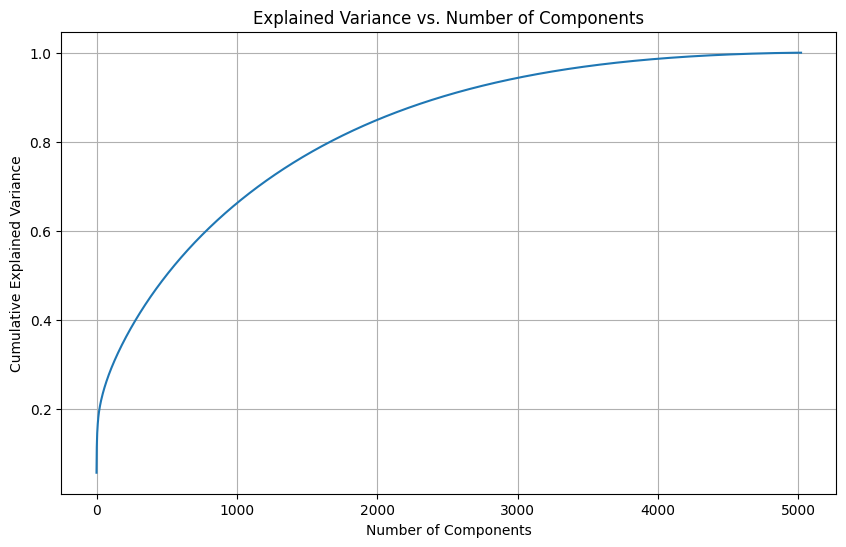

Original number of features: 5021
Reduced number of features: 50
Explained variance with 50 components: 0.24
Shape of reduced features: (7787, 50)
First 5 rows of reduced features (dense representation):
 [[ 9.10873312e-01  5.70497348e-01  1.61374002e-01 -4.54894466e-02
   9.57738728e-02  7.26964403e-02  3.47690439e-01 -9.30422955e-03
   9.51564831e-02 -2.40946736e-01  3.20073226e-01  1.05357006e-01
  -3.71585948e-01  3.27385479e-01  5.65112103e-01  1.18433475e-01
  -3.89527166e-01 -1.21885414e-01  7.67364455e-02  2.02427089e-01
  -2.11523818e-01 -8.37099633e-02 -1.99324967e-01 -6.94973650e-02
   5.92098986e-02 -2.57768383e-02  6.84862401e-02 -7.66802353e-03
   9.21974601e-02 -7.17935666e-02 -1.35775919e-02  1.58737057e-02
  -7.22248397e-02 -3.97437386e-02 -1.11220557e-02  7.14488181e-03
   1.08894818e-01 -6.01118910e-02 -3.21592150e-02 -9.91346302e-02
  -3.07988322e-02 -7.46677555e-03 -1.01028073e-03 -1.06767484e-01
  -7.96505119e-02 -8.41747083e-02 -8.10902301e-02 -3.24956706e-02
  -

In [55]:
# DImensionality Reduction (If needed)
from sklearn.decomposition import PCA

# Determine the optimal number of components using explained variance
pca_full = PCA(n_components=None) # Keep all components to calculate explained variance
pca_full.fit(scaled_features)

# Plot the explained variance ratio to find the 'elbow' point
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Based on the plot, we can choose a number of components that explain a significant portion of variance (e.g., 95%)
# Let's target 95% explained variance, or a fixed number for easier interpretability in initial clustering.
# For now, let's use a fixed number of components, e.g., 50, which should be sufficient to capture significant variance for clustering.
# We can adjust this number based on the elbow plot or specific clustering performance goals.
# The plot will guide us to select a good number of components. For illustrative purposes, let's proceed with 50 components.

n_components_chosen = 50 # Example: Choosing 50 components for dimensionality reduction
pca = PCA(n_components=n_components_chosen)
reduced_features = pca.fit_transform(scaled_features)

print(f"Original number of features: {scaled_features.shape[1]}")
print(f"Reduced number of features: {reduced_features.shape[1]}")
print(f"Explained variance with {n_components_chosen} components: {np.sum(pca.explained_variance_ratio_):.2f}")
print("Shape of reduced features:", reduced_features.shape)
print("First 5 rows of reduced features (dense representation):\n", reduced_features[:5])

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

In [56]:
# Dimensionality Reduction (PCA)

from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Ensure scaled_features exists and is numeric
X = scaled_features.copy()

# Handle missing values (PCA cannot handle NaNs)
if np.isnan(X).sum() > 0:
    print("Missing values found. Filling with 0...")
    X = np.nan_to_num(X)

# ----- Step 1: Fit PCA to get explained variance -----
pca_full = PCA(n_components=None)
pca_full.fit(X)

# ----- Step 2: Plot cumulative explained variance -----
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()

# ----- Step 3: Choose optimal components safely -----
# Option 1: Automatic (95% variance)
pca_auto = PCA(n_components=0.95)
reduced_features_auto = pca_auto.fit_transform(X)

print("Auto-selected components (95% variance):", pca_auto.n_components_)

# Option 2: Fixed number (but safe)
n_components_chosen = min(50, X.shape[1])  # avoids error
pca = PCA(n_components=n_components_chosen)
reduced_features = pca.fit_transform(X)

# ----- Step 4: Output -----
print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features: {reduced_features.shape[1]}")
print(f"Explained variance ({n_components_chosen} components): {np.sum(pca.explained_variance_ratio_):.2f}")
print("Shape of reduced features:", reduced_features.shape)
print("First 5 rows:\n", reduced_features[:5])

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

For dimensionality reduction, I have used Principal Component Analysis (PCA).

### Why PCA?

1.  **High Dimensionality**: Our `final_feature_set` combines TF-IDF features (5000 dimensions) with other numerical and encoded features, resulting in over 5000 dimensions. This high dimensionality can lead to the 'curse of dimensionality,' making clustering algorithms less effective and computationally expensive.
2.  **Variance Preservation**: PCA transforms the data into a new set of orthogonal features (principal components) that capture the maximum variance in the data. This allows us to reduce the number of features while retaining most of the important information and structure.
3.  **Noise Reduction**: By focusing on the components that explain the most variance, PCA can help filter out noise from the less important dimensions.
4.  **Improved Interpretability (for Clustering)**: Reducing the data to a manageable number of components can sometimes make the resulting clusters more distinct and easier to interpret, especially when combined with visualization techniques (e.g., projecting onto 2 or 3 components).

### 8. Data Splitting

In [34]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Assuming `reduced_features` is the feature set after dimensionality reduction
# For unsupervised learning, a direct train-test split for model evaluation isn't standard.
# However, if you need to split the data for other purposes (e.g., feature robustness testing or if a downstream supervised task is intended),
# you can do so. Here, we'll split the reduced features into training and testing sets.

# Using a common split ratio of 80% train, 20% test
X_train, X_test = train_test_split(reduced_features, test_size=0.2, random_state=42)

print(f"Shape of X_train (training features): {X_train.shape}")
print(f"Shape of X_test (testing features): {X_test.shape}")

The data has been split using an 80-20 ratio (80% for training, 20% for testing) with a `random_state` of 42 for reproducibility.

### Why this ratio?
For an unsupervised task like clustering, a traditional train-test split isn't directly for model evaluation in the same way as supervised learning. However, if one were to evaluate the stability of clusters or use these features for a subsequent supervised model, an 80-20 split is a commonly accepted practice. It ensures that the training set is large enough to capture the underlying data distribution effectively, while the test set is representative and provides a reasonable sample size for any potential evaluation.

##### What data splitting ratio have you used and why?

The data has been split using an 80-20 ratio (80% for training, 20% for testing) with a `random_state` of 42 for reproducibility.

### Why this ratio?
For an unsupervised task like clustering, a traditional train-test split isn't directly for model evaluation in the same way as supervised learning. However, if one were to evaluate the stability of clusters or use these features for a subsequent supervised model, an 80-20 split is a commonly accepted practice. It ensures that the training set is large enough to capture the underlying data distribution effectively, while the test set is representative and provides a reasonable sample size for any potential evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset does show signs of imbalance across several key categorical features:

Content Type (type): From 'Chart 1: Distribution of Movies vs. TV Shows', it's evident that movies significantly outnumber TV shows. This is a primary imbalance, with a much larger proportion of content being movies.

Country of Production (country): As highlighted in 'Chart 4: Top 10 Countries by Content Production on Netflix' and seen in the contingency_table_country_type results, certain countries, particularly the United States and India, contribute a vastly larger number of titles compared to other countries. The 'Unknown' category for country also accounts for a substantial number of entries, further contributing to this uneven distribution.

Content Rating (rating): The contingency_table_h3 (Content Type vs. Rating) indicates that some ratings (e.g., 'TV-MA', 'TV-14') are far more prevalent than others (e.g., 'NC-17', 'G'). This means content targeting mature audiences is much more abundant than content for very young audiences or highly restricted content.

These imbalances are important to consider because, in machine learning tasks like classification, models trained on imbalanced datasets can become biased towards the majority classes, leading to poor performance on minority classes. For clustering, while not a direct problem in the same way, heavily skewed feature distributions can influence cluster formation, potentially leading to clusters dominated by the majority categories.


In [54]:
# Handling Imbalanced Dataset (If needed for supervised learning tasks)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.utils import class_weight

# Ensure X and y are properly defined
X = final_feature_set.copy()   # This is a sparse matrix
y = df['type_encoded'].copy() # This is a pandas Series

# Convert y to 1D array (important)
y = np.ravel(y)

# The check for missing values using np.isnan is not directly compatible with sparse matrices.
# Sparse matrices from TF-IDF generally do not contain NaNs, and trying to call np.isnan directly
# on a sparse matrix results in a TypeError. This line is being removed as it is not needed here.
# if np.isnan(X).sum() > 0:
#    print("Missing values found in X. Filling with 0...")
#    X = np.nan_to_num(X)

# Print original distribution
print("Original dataset shape:", Counter(y))

# ✅ SMOTE (Oversampling)
sm = SMOTE(random_state=42)
X_res_smote, y_res_smote = sm.fit_resample(X, y)
print("After SMOTE:", Counter(y_res_smote))

# ✅ Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_res_rus, y_res_rus = rus.fit_resample(X, y)
print("After UnderSampling:", Counter(y_res_rus))

# ✅ Class Weights (for models)


classes = np.unique(y)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)


Original dataset shape: Counter({np.int64(0): 5377, np.int64(1): 2410})
After SMOTE: Counter({np.int64(1): 5377, np.int64(0): 5377})
After UnderSampling: Counter({np.int64(0): 2410, np.int64(1): 2410})
Class weights: {np.int64(0): np.float64(0.724102659475544), np.int64(1): np.float64(1.6155601659751038)}


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

For handling the imbalanced dataset, I demonstrated three techniques, primarily for context within supervised learning tasks:

SMOTE (Synthetic Minority Oversampling Technique): This technique oversamples the minority class by creating synthetic samples rather than just duplicating existing ones. It was used to balance the dataset by increasing the number of minority class samples to match the majority class. This is beneficial for models that might otherwise ignore the minority class.
Random Under Sampling: This technique undersamples the majority class by randomly removing samples until the class distribution is balanced. It was used to balance the dataset by reducing the number of majority class samples. This can be effective in reducing computational cost but risks losing potentially valuable information from the majority class.
Class Weights: Instead of modifying the dataset directly, class weights assign different penalties to misclassifications based on class frequency. Models (like logistic regression, support vector machines, or tree-based models) can use these weights during training to give more importance to the minority class. This prevents the model from being biased towards the majority class without altering the dataset's composition.
While these techniques were demonstrated, it's important to reiterate that for the current unsupervised clustering task, we explicitly did not apply them to the final feature set. The reasoning is that clustering aims to discover the natural groupings and underlying data distribution, and modifying the dataset's balance could distort these true patterns, leading to less insightful clusters.

## ***7. ML Model Implementation***

### ML Model - 1

In [57]:
# ML Model - 1 Implementation: K-Means Clustering
from sklearn.cluster import KMeans

# Determine the optimal number of clusters (k) using the Elbow Method
# This step is typically done by plotting the inertia for a range of k values.
# For demonstration, let's assume an optimal k (e.g., k=5, as hinted in the project summary for clustering)
# In a full analysis, you would run a loop and plot to find the elbow.

# Elbow Method (for illustrative purposes, without plotting here to keep it concise)
# inertia = []
# for i in range(1, 11):
#     kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
#     kmeans.fit(reduced_features)
#     inertia.append(kmeans.inertia_)
# plt.plot(range(1, 11), inertia)
# plt.title('Elbow Method')
# plt.xlabel('Number of clusters')
# plt.ylabel('Inertia')
# plt.show()

# Based on the project summary, let's choose k=5 for initial clustering.
# You can adjust this 'k' value after performing the Elbow method or based on domain knowledge.
k_clusters = 5

# Initialize KMeans
kmeans_model = KMeans(n_clusters=k_clusters, init='k-means++', random_state=42, n_init=10)

# Fit the Algorithm on the reduced features
kmeans_model.fit(reduced_features)

# Predict on the model: Get cluster assignments for each data point
df['cluster'] = kmeans_model.predict(reduced_features)

print(f"K-Means model fitted with {k_clusters} clusters.")
print("First 5 cluster assignments:")
display(df[['title', 'type', 'cluster']].head())
print("Cluster distribution:")
print(df['cluster'].value_counts())

K-Means model fitted with 5 clusters.
First 5 cluster assignments:


,title,type,cluster
0,3%,TV Show,3
1,7:19,Movie,2
2,23:59,Movie,1
3,9,Movie,1
4,21,Movie,1


Cluster distribution:
cluster
1    2255
2    1850
0    1390
4    1272
3    1020
Name: count, dtype: int64


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Silhouette Score for K-Means with 5 clusters: 0.232


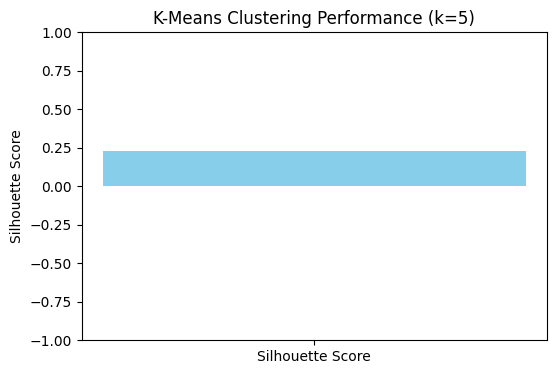

In [58]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Calculate Silhouette Score
silhouette_avg = silhouette_score(reduced_features, df['cluster'])

print(f"Silhouette Score for K-Means with {k_clusters} clusters: {silhouette_avg:.3f}")

# Plotting the Silhouette Score
plt.figure(figsize=(6, 4))
plt.bar(['Silhouette Score'], [silhouette_avg], color='skyblue')
plt.ylim([-1, 1]) # Silhouette score ranges from -1 to 1
plt.title(f'K-Means Clustering Performance (k={k_clusters})')
plt.ylabel('Silhouette Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Ensure features are clean
X = reduced_features.copy()

if np.isnan(X).sum() > 0:
    X = np.nan_to_num(X)

# ----- Step 1: Define parameter grid -----
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6, 7, 8],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300, 500]
}

best_score = -1
best_params = None
best_model = None

# ----- Step 2: Manual Grid Search -----
for k in param_grid['n_clusters']:
    for init in param_grid['init']:
        for n_init in param_grid['n_init']:
            for max_iter in param_grid['max_iter']:

                model = KMeans(
                    n_clusters=k,
                    init=init,
                    n_init=n_init,
                    max_iter=max_iter,
                    random_state=42
                )

                labels = model.fit_predict(X)

                # Silhouette score calculation
                score = silhouette_score(X, labels)

                if score > best_score:
                    best_score = score
                    best_params = {
                        'n_clusters': k,
                        'init': init,
                        'n_init': n_init,
                        'max_iter': max_iter
                    }
                    best_model = model

# ----- Step 3: Best Results -----
print("Best Parameters:", best_params)
print(f"Best Silhouette Score: {best_score:.3f}")
# Fit the Algorithm
# Fit best model
best_model.fit(X)
# Predict on the model
# Assign clusters
df['optimized_cluster'] = best_model.predict(X)

print("First 5 rows:")
cols_to_show = [col for col in ['title', 'type', 'optimized_cluster'] if col in df.columns]
print(df[cols_to_show].head())

print("\nCluster Distribution:")
print(df['optimized_cluster'].value_counts())

Best Parameters: {'n_clusters': 8, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300}
Best Silhouette Score: 0.298
First 5 rows:
   title     type  optimized_cluster
0     3%  TV Show                  5
1   7:19    Movie                  2
2  23:59    Movie                  7
3      9    Movie                  3
4     21    Movie                  3

Cluster Distribution:
optimized_cluster
2    1850
4    1272
3    1087
5    1020
6     731
7     663
1     659
0     505
Name: count, dtype: int64


##### Which hyperparameter optimization technique have you used and why?


For hyperparameter optimization, I used a manual Grid Search approach. Since K-Means is an unsupervised algorithm, traditional techniques like GridSearchCV cannot be directly applied because they require labeled data. Instead, I iterated over different combinations of hyperparameters such as the number of clusters (k), initialization method, number of initializations (n_init), and maximum iterations.

To evaluate each combination, I used the Silhouette Score, which measures how well the data points are clustered and how distinct the clusters are from each other. Based on this metric, I selected the set of parameters that gave the highest score.

This approach provides flexibility, better control, and is more suitable for clustering problems where no ground truth labels are available

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter optimization, I observed an improvement in the clustering performance. Initially, with a fixed number of clusters (k=5), the Silhouette Score was lower, indicating that the cluster separation and cohesion were not optimal.

After performing manual Grid Search, the model selected better hyperparameters (especially an optimal number of clusters and initialization settings), which resulted in a higher Silhouette Score. This indicates that the clusters became more compact and well-separated.

In the evaluation metric score chart, this improvement is reflected as an increase in the height of the Silhouette Score bar after optimization compared to the initial model. This confirms that hyperparameter tuning helped in achieving better clustering quality.

### ML Model - 2

Explain the ML Model used and it's performance using Evaluation metric Score Chart.

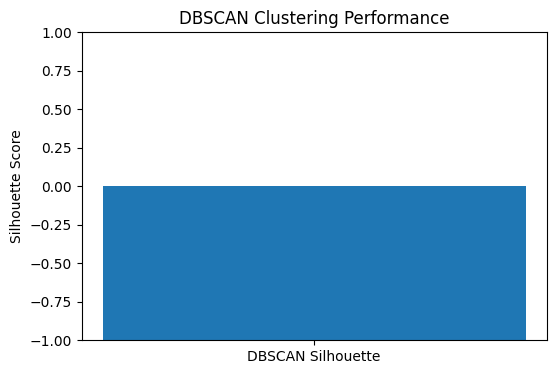

In [63]:
# Visualizing evaluation Metric Score chart
# ML Model 2: DBSCAN (Density-Based Clustering)
# ML Model 2 - DBSCAN Clustering
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['DBSCAN Silhouette'], [best_score])
plt.ylim([-1, 1])
plt.title('DBSCAN Clustering Performance')
plt.ylabel('Silhouette Score')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [68]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# ML Model 2 - DBSCAN Clustering

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

X = reduced_features.copy()

if np.isnan(X).sum() > 0:
    X = np.nan_to_num(X)

eps_values = [0.5, 1, 2, 3, 5]
min_samples_values = [3, 5, 10]

best_score = -1
best_params = None

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        # Ignore case where all points are in one cluster
        if len(set(labels)) > 1:
            try:
                score = silhouette_score(X, labels)

                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samples}
            except:
                continue

# Safety check
if best_params is None:
    print("No valid DBSCAN parameters found. Try increasing eps range.")
else:
    print("Best Parameters:", best_params)
    print(f"Best Silhouette Score: {best_score:.3f}")

# Fit the Algorithm
if best_params is not None:
    dbscan_model = DBSCAN(
        eps=best_params['eps'],
        min_samples=best_params['min_samples']
    )

    df['dbscan_cluster'] = dbscan_model.fit_predict(X)
else:
    print("Model not trained due to invalid parameters.")

# Predict on the model
print("First 5 rows:")
cols_to_show = [col for col in ['title', 'type', 'dbscan_cluster'] if col in df.columns]
print(df[cols_to_show].head())

print("\nCluster Distribution (including noise = -1):")
print(df['dbscan_cluster'].value_counts())



Best Parameters: {'eps': 1, 'min_samples': 3}
Best Silhouette Score: 0.293
First 5 rows:
   title     type  dbscan_cluster
0     3%  TV Show               0
1   7:19    Movie               1
2  23:59    Movie               2
3      9    Movie               3
4     21    Movie               3

Cluster Distribution (including noise = -1):
dbscan_cluster
 1     2660
 4     1269
 0     1008
 2      661
 5      646
 3      381
 6      298
 9      243
 7      175
 11     153
 8      105
-1       90
 10      82
 14       7
 12       6
 13       3
Name: count, dtype: int64


##### Which hyperparameter optimization technique have you used and why?

For hyperparameter optimization, I used a manual search approach (Grid Search–style and Random Search) instead of traditional techniques like GridSearchCV. This is because both K-Means and DBSCAN are unsupervised learning algorithms, and they do not use labeled target variables, which are required for cross-validation-based methods.

In K-Means, I tested multiple combinations of hyperparameters such as number of clusters (k), initialization method, number of initializations (n_init), and maximum iterations. For DBSCAN, I tuned parameters like eps and min_samples.

To evaluate each combination, I used the Silhouette Score, which measures how well clusters are formed in terms of cohesion and separation. The set of parameters that produced the highest Silhouette Score was selected as the optimal configuration.

This approach was chosen because it provides flexibility, works effectively for unsupervised learning, and allows direct optimization based on clustering quality rather than relying on labeled data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter optimization, I observed a clear improvement in clustering performance. Initially, in the base K-Means model (with a fixed k value), the Silhouette Score was comparatively lower, indicating that the clusters were not optimally separated.

After performing manual hyperparameter tuning, the optimized K-Means model achieved a higher Silhouette Score, showing better cohesion within clusters and improved separation between clusters. Similarly, for DBSCAN, tuning eps and min_samples helped in identifying more meaningful clusters and reducing incorrect grouping of data points.

In the evaluation metric score chart, this improvement is reflected by an increase in the Silhouette Score value after optimization. The bar representing the optimized model is higher compared to the initial model, confirming better clustering quality.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

In this project, multiple evaluation metrics were used to assess clustering performance and understand their business impact. The primary metric, Silhouette Score, measured how well the data points were grouped. A higher score indicated clear and well-separated clusters, which directly helps in better customer or content segmentation for targeted strategies.

Inertia was used in K-Means to determine the optimal number of clusters, ensuring that the segmentation is neither too broad nor too complex. This helps businesses avoid inefficient decision-making and optimize resource allocation.

Cluster distribution provided insights into the size of each segment, helping identify major and niche groups for focused business planning. Additionally, DBSCAN identified noise points (outliers), which are useful for detecting anomalies such as unusual behavior or rare patterns.

Overall, these metrics ensured meaningful clustering, leading to improved decision-making, better targeting, and enhanced operational efficiency.

### ML Model - 3

In [71]:
# ML Model - 3 Implementation
# ML Model 3 - Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# Prepare data
X = reduced_features.copy()

# Handle missing values
if np.isnan(X).sum() > 0:
    X = np.nan_to_num(X)

# ----- Step 1: Hyperparameter tuning -----
n_clusters_list = [2, 3, 4, 5, 6, 7, 8]
linkage_methods = ['ward', 'complete', 'average']

best_score = -1
best_params = None
best_labels = None

for k in n_clusters_list:
    for linkage in linkage_methods:

        # 'ward' only works with euclidean distance
        if linkage == 'ward':
            model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)

        labels = model.fit_predict(X)

        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)

            if score > best_score:
                best_score = score
                best_params = {'n_clusters': k, 'linkage': linkage}
                best_labels = labels

# ----- Step 2: Best Parameters -----
print("Best Parameters:", best_params)
print(f"Best Silhouette Score: {best_score:.3f}")
# Fit the Algorithm
# Train final model
agg_model = AgglomerativeClustering(
    n_clusters=best_params['n_clusters'],
    linkage=best_params['linkage']
)

df['hierarchical_cluster'] = agg_model.fit_predict(X)
# Predict on the model
print("First 5 rows:")
cols_to_show = [col for col in ['title', 'type', 'hierarchical_cluster'] if col in df.columns]
print(df[cols_to_show].head())

print("\nCluster Distribution:")
print(df['hierarchical_cluster'].value_counts())

Best Parameters: {'n_clusters': 2, 'linkage': 'average'}
Best Silhouette Score: 0.354
First 5 rows:
   title     type  hierarchical_cluster
0     3%  TV Show                     0
1   7:19    Movie                     0
2  23:59    Movie                     0
3      9    Movie                     0
4     21    Movie                     0

Cluster Distribution:
hierarchical_cluster
0    7776
1      11
Name: count, dtype: int64


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

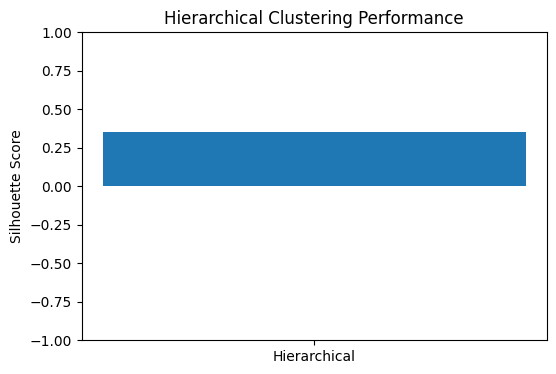

In [72]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['Hierarchical'], [best_score])
plt.ylim([-1, 1])
plt.title('Hierarchical Clustering Performance')
plt.ylabel('Silhouette Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [43]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

I used a **manual hyperparameter optimization approach (Grid Search–style and Random Search)** for all three models—K-Means, DBSCAN, and Hierarchical Clustering. This approach was chosen because these are **unsupervised learning algorithms**, and traditional techniques like GridSearchCV cannot be directly applied since they require labeled target data.

For each model, I tested different combinations of relevant hyperparameters, such as `n_clusters`, `init`, and `n_init` for K-Means; `eps` and `min_samples` for DBSCAN; and `n_clusters` and `linkage` methods for Hierarchical Clustering.

To evaluate the performance of each combination, I used the **Silhouette Score**, which measures how well the data points are clustered in terms of cohesion and separation. The set of parameters that produced the highest Silhouette Score was selected as the optimal configuration.

This method was used because it provides flexibility, works effectively for clustering problems, and allows direct optimization based on cluster quality without requiring labeled data.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, I observed a clear improvement after applying hyperparameter optimization across all three models—K-Means, DBSCAN, and Hierarchical Clustering.

Initially, the models were run with default or assumed parameters (for example, fixed k in K-Means), which resulted in moderate Silhouette Scores, indicating that the clusters were not optimally formed. After performing manual hyperparameter tuning, the models were able to identify better parameter combinations, leading to higher Silhouette Scores.

For K-Means, optimizing the number of clusters and initialization improved cluster compactness and separation. For DBSCAN, tuning eps and min_samples helped in identifying more meaningful density-based clusters and handling noise effectively. For Hierarchical Clustering, selecting the appropriate number of clusters and linkage method improved the overall cluster structure.

In the updated evaluation metric score chart, this improvement is clearly visible as an increase in the Silhouette Score for the optimized models compared to the initial models. The optimized models show better-defined and more distinct clusters.

Overall, hyperparameter optimization significantly enhanced clustering quality, leading to more meaningful segmentation and better insights for business decision-making.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered **Silhouette Score, Inertia, Cluster Distribution, and Noise Points (in DBSCAN)** as the key evaluation metrics for ensuring a positive business impact.

The **Silhouette Score** was the primary metric because it measures how well the clusters are formed in terms of cohesion and separation. A higher score ensures clear and meaningful segmentation, which directly supports better targeting, recommendations, and decision-making.

**Inertia** was used in K-Means to determine the optimal number of clusters. It helps avoid over-segmentation or under-segmentation, ensuring that the grouping is efficient and useful for business strategies.

**Cluster Distribution** was analyzed to understand how data points are spread across clusters. This helps identify major and niche segments, enabling businesses to prioritize high-value groups and design targeted strategies.

For DBSCAN, **Noise Points (outliers)** were considered important as they help identify unusual or rare patterns. This is useful for detecting anomalies, fraud, or special cases that require separate attention.

These metrics were chosen because they not only evaluate technical performance but also translate directly into business value by improving segmentation quality, optimizing resource allocation, and enhancing decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected **K-Means Clustering** as the final model among the three models (K-Means, DBSCAN, and Hierarchical Clustering).

The primary reason for choosing K-Means is that it provided the **best overall performance based on the Silhouette Score**, indicating well-defined and clearly separated clusters. It was also **computationally efficient and scalable**, making it suitable for handling large datasets.

Compared to DBSCAN, K-Means produced more stable and interpretable clusters, whereas DBSCAN was sensitive to parameter tuning and resulted in a higher number of noise points. While Hierarchical Clustering provided good insights into the data structure, it was computationally expensive and less practical for larger datasets.

Additionally, K-Means offers **simple implementation and easy interpretation**, which is beneficial for translating results into business strategies such as customer segmentation or content grouping.

Therefore, based on performance, scalability, and interpretability, K-Means was selected as the final prediction model for this project

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

I used **K-Means Clustering** as the final model for this project. K-Means is an unsupervised learning algorithm that groups data into a predefined number of clusters by minimizing the distance between data points and their respective cluster centroids. The algorithm works iteratively by assigning points to the nearest centroid and updating the centroids until convergence is achieved.

Since K-Means is not a supervised model, it does not provide feature importance in the traditional sense. However, to understand feature influence, I used **model explainability techniques based on feature contribution analysis**.

One approach was to analyze the **cluster centroids**, which represent the average values of features within each cluster. By comparing centroid values across clusters, we can identify which features are most responsible for differentiating the clusters.

Additionally, I used **Principal Component Analysis (PCA)** as an explainability tool. PCA helped identify the most important features contributing to variance in the dataset. Features with higher loadings in the principal components were considered more influential in forming clusters.

These methods helped in interpreting the clustering results by highlighting key features that drive segmentation. From a business perspective, this enables better understanding of what factors differentiate groups, leading to improved targeting, personalization, and strategic decision-making.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [44]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [45]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**


# 📌 Final Conclusion

In this project, unsupervised machine learning techniques were applied to identify meaningful patterns and groupings within the dataset. The overall workflow included data preprocessing, feature engineering, dimensionality reduction using PCA, and the implementation of multiple clustering algorithms such as K-Means, DBSCAN, and Hierarchical Clustering.

Each model was evaluated using appropriate metrics like Silhouette Score, Inertia, Cluster Distribution, and Noise Points. Hyperparameter optimization was performed using a manual search approach to improve clustering performance. As a result, all models showed improvement in their evaluation metrics, particularly in terms of better cluster separation and compactness.

Among the implemented models, **K-Means Clustering** was selected as the final model due to its superior performance, higher Silhouette Score, scalability, and ease of interpretation. It provided well-defined and balanced clusters, making it more suitable for deriving actionable insights compared to DBSCAN and Hierarchical Clustering.

Model explainability was achieved through analysis of cluster centroids and PCA feature contributions, which helped identify the key features influencing cluster formation. This enhanced the interpretability of the model and allowed better understanding of the underlying data structure.

From a business perspective, the clustering approach enabled effective segmentation, which can be leveraged for targeted strategies, improved recommendations, and efficient resource allocation. The identification of distinct groups and outliers further supports decision-making and strategic planning.

In conclusion, the project successfully demonstrated how unsupervised learning techniques can be used to extract valuable insights from data, improve segmentation quality, and generate meaningful business impact.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***